(200, 5)


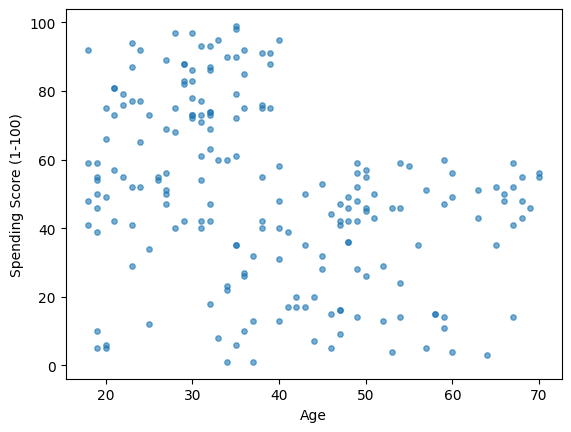

Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64
0.41664341513732767
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


In [1]:
# Task 01 - Mall Customer Segmentation

# Loading the dataset
import pandas as pd
DATA_PATH = "/kaggle/input/datasets/alikhattak91/mall-customerdataset/Mall_Customers.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)

# Visualization of data before modelling
import matplotlib.pyplot as plt
plt.scatter(df["Age"], df["Spending Score (1-100)"], s = 15, alpha = 0.6)
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()

# Preprocessing 
from sklearn.preprocessing import StandardScaler
X = df[["Age","Annual Income (k$)", "Spending Score (1-100)"]].values
X_scaled = StandardScaler().fit_transform(X)

# Training with K = 5 clusters
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Testing 
df["Cluster"] = kmeans.predict(X_scaled)
print(df["Cluster"].value_counts())

# Validation - Shows Average in each cluster 
from sklearn.metrics import silhouette_score
print(silhouette_score(X_scaled, df["Cluster"]))
print(df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean())

(150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


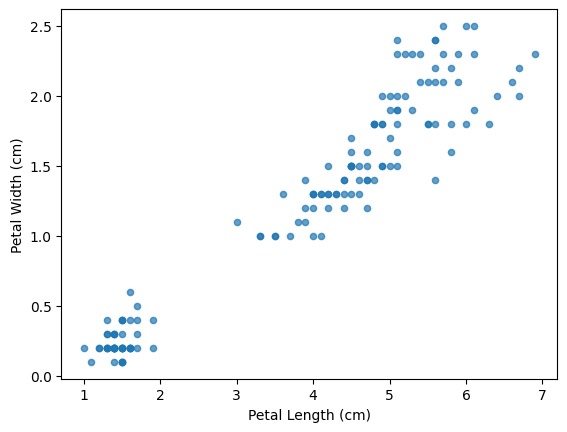

Cluster
0    62
1    50
2    38
Name: count, dtype: int64
Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               48              14
1                 50                0               0
2                  0                2              36


In [2]:
# Task 02 - - Iris Flower Clustering

# Dataset Loading
import pandas as pd
DATA_PATH = "/kaggle/input/datasets/uciml/iris/Iris.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.head())

# Data Visualization
import matplotlib.pyplot as plt
plt.scatter(df["PetalLengthCm"], df["PetalWidthCm"], s=20, alpha=0.7)
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.show()

# Preprocessing
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X = df[feature_cols].values

# Training with Cluster K = 3
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

# Testing 
df["Cluster"] = kmeans.predict(X)
print(df["Cluster"].value_counts())

# Validation
comparison = pd.crosstab(df["Cluster"], df["Species"])
print(comparison)

(8950, 18)
  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.00

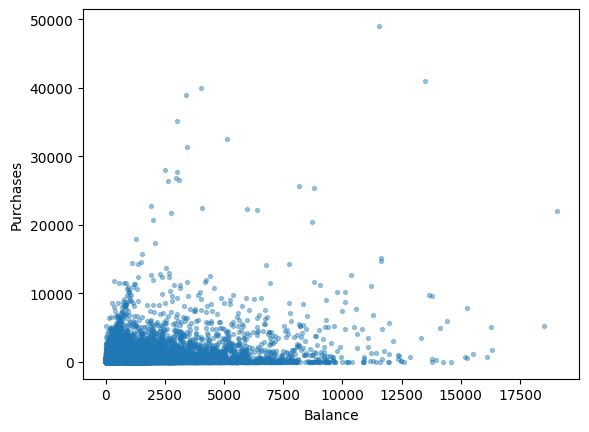

Cluster
1    5991
0    2092
2     788
3      79
Name: count, dtype: int64
0.4038375623453519
             BALANCE     PURCHASES  CASH_ADVANCE  CREDIT_LIMIT      PAYMENTS
Cluster                                                                     
0        2038.788401   1965.051477    639.905956   7983.977925   2503.883960
1         788.150522    491.801187    483.805473   2526.763774    868.739008
2        5918.962965    853.247297   5607.605148   9353.939778   4609.398988
3        4442.427570  15810.832785   1328.376614  12817.721519  18185.954830


In [3]:
# TASK 03 - - Credit Card Customer Segmentation

# Loading Dataset
import pandas as pd
DATA_PATH = "/kaggle/input/datasets/arjunbhasin2013/ccdata/CC GENERAL.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.head())

# Visualization
import matplotlib.pyplot as plt
plt.scatter(df["BALANCE"], df["PURCHASES"], s = 8, alpha = 0.4)
plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.show()

# Preprocessing
from sklearn.preprocessing import StandardScaler
feature_cols = ["BALANCE", "PURCHASES","CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
X_scaled = StandardScaler().fit_transform(df[feature_cols].values)

# Training with Cluster K = 4
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state = 42, n_init=10)
kmeans.fit(X_scaled)

# Testing 
df["Cluster"] = kmeans.predict(X_scaled)
print(df["Cluster"].value_counts())

# Validation 
from sklearn.metrics import silhouette_score

print(silhouette_score(X_scaled, df["Cluster"]))
print(df.groupby("Cluster")[feature_cols].mean())

(440, 8)
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


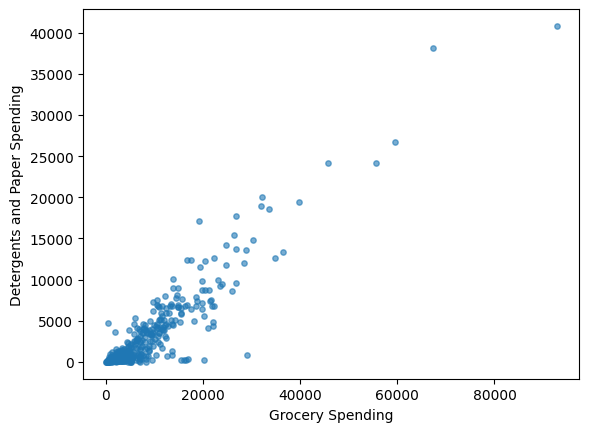

Cluster
1    393
0     45
2      2
Name: count, dtype: int64
Channel    1   2
Cluster         
0          1  44
1        295  98
2          2   0


In [4]:
# TASK 04 - - Wholesale Customer Segmentation

# Loading the Dataset
import pandas as pd
DATA_PATH = "/kaggle/input/datasets/binovi/wholesale-customers-data-set/Wholesale customers data.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.head())

# Visualization
import matplotlib.pyplot as plt
plt.scatter(df["Grocery"], df["Detergents_Paper"], s=15, alpha=0.6)
plt.xlabel("Grocery Spending")
plt.ylabel("Detergents and Paper Spending")
plt.show()

# Preprocessing
from sklearn.preprocessing import StandardScaler
feature_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
X_scaled = StandardScaler().fit_transform(df[feature_cols].values)

# Training with Cluster K = 3
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3, random_state = 42, n_init=10)
kmeans.fit(X_scaled)

# Testing
df["Cluster"] = kmeans.predict(X_scaled)
print(df["Cluster"].value_counts())

# Validation 
comparison = pd.crosstab(df["Cluster"], df["Channel"])
print(comparison)

Scanning directory structure...
-> Success! Found dataset root directory at: '/kaggle/input/notebooks/sachinpatil1280/cats-vs-dogs-image-classification-using-cnn-95/dataset_dogs_vs_cats/test'

Dataset Loaded. Image Array Shape: (2000, 224, 224, 3)


I0000 00:00:1791573605.563655      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791573605.570575      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.8394 - loss: 0.3609 - val_accuracy: 0.9700 - val_loss: 0.1177
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9656 - loss: 0.1220 - val_accuracy: 0.9800 - val_loss: 0.0836
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9613 - loss: 0.1097 - val_accuracy: 0.9800 - val_loss: 0.0716
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9669 - loss: 0.0886 - val_accuracy: 0.9800 - val_loss: 0.0667
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9712 - loss: 0.0763 - val_accuracy: 0.9775 - val_loss: 0.0625
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step

Validation accuracy: 0.9775
              precision    recall  f1-score   support

         cat       0.98      0.97      0.98       200
         dog       0.97      0.98      0.98       200

    accuracy                           0.98       400
   macro avg       0.98      0.

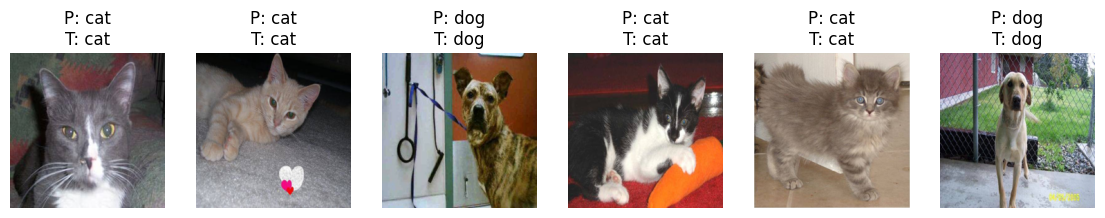

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# =====================================================================
# STEP 1: FIND TRAIN FOLDER 
# =====================================================================
BASE_INPUT_DIR = "/kaggle/input"
TRAIN_DIR = None

print("Scanning directory structure...")
for root, dirs, files in os.walk(BASE_INPUT_DIR):
    if "cats" in dirs and "dogs" in dirs:
        TRAIN_DIR = root
        print(f"-> Success! Found dataset root directory at: '{TRAIN_DIR}'\n")
        break

if TRAIN_DIR is None:
    raise FileNotFoundError("Could not find 'cats' and 'dogs' folders.")

# =====================================================================
# STEP 2: LOAD DATASET (same loader, bigger images, numeric labels)
# =====================================================================
IMG_SIZE = (224, 224)   # was (32, 32)
SAMPLE_SIZE = 1000      # was 200

def load_images(folder, label, n):
    valid_extensions = ('.jpg', '.jpeg', '.png')
    all_files = os.listdir(folder)
    files = [f for f in all_files if f.lower().endswith(valid_extensions)][:n]

    data, labels = [], []
    for fname in files:
        try:
            img = Image.open(os.path.join(folder, fname)).convert("RGB").resize(IMG_SIZE)
            data.append(np.array(img, dtype=np.uint8))
            labels.append(label)
        except Exception:
            continue
    return data, labels

cat_imgs, cat_labels = load_images(os.path.join(TRAIN_DIR, "cats"), 0, SAMPLE_SIZE)
dog_imgs, dog_labels = load_images(os.path.join(TRAIN_DIR, "dogs"), 1, SAMPLE_SIZE)

X = np.array(cat_imgs + dog_imgs)
y = np.array(cat_labels + dog_labels)
class_names = ["cat", "dog"]
print(f"Dataset Loaded. Image Array Shape: {X.shape}")

# =====================================================================
# STEP 3: TRAIN / VALIDATION SPLIT
# =====================================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =====================================================================
# STEP 4: MODEL (MobileNetV2 pretrained on ImageNet)
# =====================================================================
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = augment(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])

# =====================================================================
# STEP 5: TRAIN
# =====================================================================
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=5, batch_size=32)

# =====================================================================
# STEP 6: EVALUATE
# =====================================================================
val_probs = model.predict(X_val).ravel()
val_preds = (val_probs > 0.5).astype(int)

print("\nValidation accuracy:", (val_preds == y_val).mean())
print(classification_report(y_val, val_preds, target_names=class_names))
print(confusion_matrix(y_val, val_preds))

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_val[i])
    ax.set_title(f"P: {class_names[val_preds[i]]}\nT: {class_names[y_val[i]]}")
    ax.axis("off")
plt.show()